In [ ]:
# ==========================================
# Step 1 : Install Required Libraries
# ==========================================

!pip install torch torchvision matplotlib pillow tqdm

In [ ]:
# ==========================================
# Step 2 : Import Required Libraries
# ==========================================

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageDraw

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.utils import save_image
from torch.utils.data import DataLoader

from tqdm import tqdm

In [ ]:
# ==========================================
# Step 3 : Check Device
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : Tesla T4


In [ ]:
# ==========================================
# Step 4 : Generate Shape Dataset
# ==========================================


IMAGE_SIZE = 64
DRAW_SIZE = 256
NUM_IMAGES = 800
classes = ["circle", "square", "triangle"]

dataset_path = "shape_dataset"

if os.path.exists(dataset_path):
    shutil.rmtree(dataset_path)

os.makedirs(dataset_path, exist_ok=True)

for shape in classes:

    folder = os.path.join(dataset_path, shape)
    os.makedirs(folder, exist_ok=True)

    print(f"Generating {shape} images...")

    for i in range(NUM_IMAGES):

        img = Image.new("RGB", (DRAW_SIZE, DRAW_SIZE), "white")
        draw = ImageDraw.Draw(img)

        color = (
            random.randint(20, 200),
            random.randint(20, 200),
            random.randint(20, 200)
        )

        size = random.randint(120, 190)

        cx = DRAW_SIZE // 2 + random.randint(-15, 15)
        cy = DRAW_SIZE // 2 + random.randint(-15, 15)

        left = cx - size // 2
        top = cy - size // 2
        right = cx + size // 2
        bottom = cy + size // 2

        if shape == "circle":
            draw.ellipse([left, top, right, bottom], fill=color)

        elif shape == "square":
            draw.rectangle([left, top, right, bottom], fill=color)

        else:  # triangle
            draw.polygon(
                [(cx, top), (left, bottom), (right, bottom)],
                fill=color
            )

        img = img.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.LANCZOS)

        img.save(os.path.join(folder, f"{shape}_{i}.png"))

print("\nDataset Created Successfully!")
print(f"Total Images : {len(classes) * NUM_IMAGES}")

Generating circle images...
Generating square images...
Generating triangle images...

Dataset Created Successfully!
Total Images : 2400


Dataset Loaded Successfully
Number of Images : 2400
Classes          : ['circle', 'square', 'triangle']

Image Batch Shape : torch.Size([32, 3, 64, 64])
Label Batch Shape : torch.Size([32])


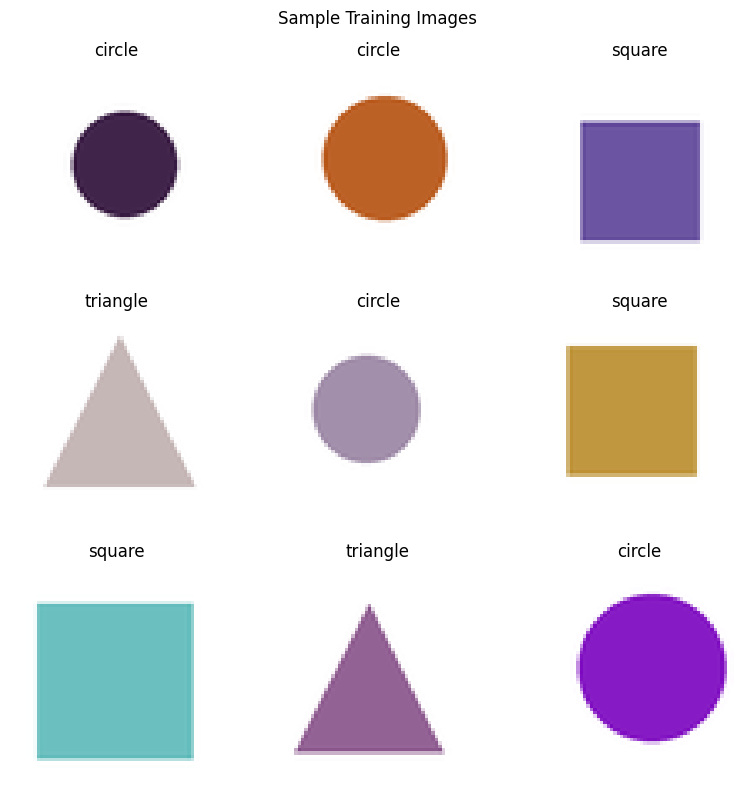

In [ ]:
# ==========================================
# Step 5 : Load Dataset & Visualize Samples
# ==========================================

BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.ImageFolder(root="shape_dataset", transform=transform)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    drop_last=True
)

print("=" * 40)
print("Dataset Loaded Successfully")
print("=" * 40)
print("Number of Images :", len(dataset))
print("Classes          :", dataset.classes)

images, labels = next(iter(dataloader))
print("\nImage Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

class_names = dataset.classes

plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    image = images[i].permute(1, 2, 0).numpy()
    image = (image * 0.5) + 0.5
    image = np.clip(image, 0, 1)
    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Step 6 : Self-Attention Layer
# ==========================================
class SelfAttention(nn.Module):

    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()

        self.query_conv = nn.utils.spectral_norm(nn.Conv2d(in_channels, in_channels // 8, kernel_size=1))
        self.key_conv = nn.utils.spectral_norm(nn.Conv2d(in_channels, in_channels // 8, kernel_size=1))
        self.value_conv = nn.utils.spectral_norm(nn.Conv2d(in_channels, in_channels, kernel_size=1))

        # learnable weight that controls how much attention contributes.
        # starts at 0 so training begins close to a normal conv network
        # and gradually learns to use attention.
        self.gamma = nn.Parameter(torch.zeros(1))

        self.softmax = nn.Softmax(dim=-1)

        # stores the last attention map, only used for visualization later
        self.attention_map = None

    def forward(self, x):

        batch_size, C, width, height = x.size()
        N = width * height

        query = self.query_conv(x).view(batch_size, -1, N).permute(0, 2, 1)  # B x N x C'
        key = self.key_conv(x).view(batch_size, -1, N)                       # B x C' x N

        attention = torch.bmm(query, key)          # B x N x N
        attention = self.softmax(attention)

        self.attention_map = attention.detach()

        value = self.value_conv(x).view(batch_size, -1, N)  # B x C x N

        out = torch.bmm(value, attention.permute(0, 2, 1))  # B x C x N
        out = out.view(batch_size, C, width, height)

        out = self.gamma * out + x  # residual connection

        return out

In [ ]:
# ==========================================
# Test Self-Attention Layer
# ==========================================

sample = torch.randn(4, 64, 32, 32)

attention_test = SelfAttention(64)

output = attention_test(sample)

print("Input Shape  :", sample.shape)
print("Output Shape :", output.shape)

Input Shape  : torch.Size([4, 64, 32, 32])
Output Shape : torch.Size([4, 64, 32, 32])


In [ ]:
# ==========================================
# Step 7 : Generator (with Self-Attention)
# ==========================================
LATENT_DIM = 100
NUM_CLASSES = 3

def sn_conv(in_ch, out_ch, kernel_size=3, stride=1, padding=1):
    return nn.utils.spectral_norm(nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding))

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.label_embedding = nn.Embedding(NUM_CLASSES, LATENT_DIM)

        self.fc = nn.Sequential(
            nn.Linear(LATENT_DIM * 2, 512 * 4 * 4),
            nn.BatchNorm1d(512 * 4 * 4),
            nn.ReLU(True)
        )

        self.block1 = nn.Sequential(          # 4x4 -> 8x8
            nn.Upsample(scale_factor=2, mode="nearest"),
            sn_conv(512, 256),
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        self.block2 = nn.Sequential(          # 8x8 -> 16x16
            nn.Upsample(scale_factor=2, mode="nearest"),
            sn_conv(256, 128),
            nn.BatchNorm2d(128),
            nn.ReLU(True)
        )

        self.attention = SelfAttention(128)   # applied at 16x16

        self.block3 = nn.Sequential(          # 16x16 -> 32x32
            nn.Upsample(scale_factor=2, mode="nearest"),
            sn_conv(128, 64),
            nn.BatchNorm2d(64),
            nn.ReLU(True)
        )

        self.output = nn.Sequential(          # 32x32 -> 64x64
            nn.Upsample(scale_factor=2, mode="nearest"),
            sn_conv(64, 3),
            nn.Tanh()
        )

    def forward(self, noise, labels):

        label_embed = self.label_embedding(labels)

        x = torch.cat((noise, label_embed), dim=1)

        x = self.fc(x)
        x = x.view(-1, 512, 4, 4)

        x = self.block1(x)
        x = self.block2(x)
        x = self.attention(x)
        x = self.block3(x)

        img = self.output(x)

        return img

In [ ]:
# ==========================================
# Test Generator
# ==========================================

generator = Generator().to(device)

noise = torch.randn(8, LATENT_DIM).to(device)
labels = torch.randint(0, NUM_CLASSES, (8,), device=device)

output = generator(noise, labels)

print("Output Shape :", output.shape)   # expected: [8, 3, 64, 64]

Output Shape : torch.Size([8, 3, 64, 64])


In [ ]:
# ==========================================
# Step 8 : Discriminator (with Self-Attention)
# ==========================================
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.label_embedding = nn.Embedding(NUM_CLASSES, IMAGE_SIZE * IMAGE_SIZE)

        self.model = nn.Sequential(

            # input: (3 + 1) x 64 x 64
            sn_conv(4, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 32x32
            sn_conv(64, 128, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # self attention at 16x16
            SelfAttention(128),

            # 8x8
            sn_conv(128, 256, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4
            sn_conv(256, 512, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            # 4x4 -> 1x1
            sn_conv(512, 1, 4, 1, 0)
        )

    def forward(self, images, labels):

        label_map = self.label_embedding(labels)
        label_map = label_map.view(-1, 1, IMAGE_SIZE, IMAGE_SIZE)

        x = torch.cat((images, label_map), dim=1)

        out = self.model(x)

        return out.view(-1)

In [ ]:
# ==========================================
# Test Discriminator
# ==========================================

discriminator = Discriminator().to(device)

images_test = torch.randn(8, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
labels_test = torch.randint(0, NUM_CLASSES, (8,), device=device)

output = discriminator(images_test, labels_test)

print("Image Shape  :", images_test.shape)
print("Output Shape :", output.shape)   # expected: [8]

Image Shape  : torch.Size([8, 3, 64, 64])
Output Shape : torch.Size([8])


In [ ]:
# ==========================================
# Step 9 : Loss and Optimizers
# ==========================================
LEARNING_RATE_G = 0.0001
LEARNING_RATE_D = 0.0004
BETA1 = 0.0
BETA2 = 0.9
EPOCHS = 100

criterion = nn.BCEWithLogitsLoss()

optimizer_G = optim.Adam(generator.parameters(), lr=LEARNING_RATE_G, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LEARNING_RATE_D, betas=(BETA1, BETA2))

print("=" * 50)
print("Training Configuration")
print("=" * 50)
print(f"Image Size          : {IMAGE_SIZE}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Latent Dimension    : {LATENT_DIM}")
print(f"Generator LR        : {LEARNING_RATE_G}")
print(f"Discriminator LR    : {LEARNING_RATE_D}")
print(f"Epochs              : {EPOCHS}")
print()
print("Generator and Discriminator ready, optimizers initialized.")

Training Configuration
Image Size          : 64
Batch Size          : 32
Latent Dimension    : 100
Generator LR        : 0.0001
Discriminator LR    : 0.0004
Epochs              : 100

Generator and Discriminator ready, optimizers initialized.


In [ ]:
# ==========================================
# Step 10 : Train Self-Attention Conditional GAN
# ==========================================

os.makedirs("generated_images", exist_ok=True)

fixed_noise = torch.randn(9, LATENT_DIM, device=device)
fixed_labels = torch.tensor([0, 1, 2, 0, 1, 2, 0, 1, 2], device=device)

G_losses = []
D_losses = []

generator.train()
discriminator.train()

for epoch in range(EPOCHS):

    g_loss_epoch = 0.0
    d_loss_epoch = 0.0

    loop = tqdm(dataloader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    for images, labels in loop:

        images = images.to(device)
        labels = labels.to(device)

        batch_size = images.size(0)

        # -----------------------------
        # Train Discriminator
        # -----------------------------

        optimizer_D.zero_grad()

        real_targets = torch.ones(batch_size, device=device)
        fake_targets = torch.zeros(batch_size, device=device)

        real_output = discriminator(images, labels)
        d_real_loss = criterion(real_output, real_targets)

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = generator(noise, labels)

        fake_output = discriminator(fake_images.detach(), labels)
        d_fake_loss = criterion(fake_output, fake_targets)

        d_loss = (d_real_loss + d_fake_loss) / 2
        d_loss.backward()

        torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 1.0)
        optimizer_D.step()

        # -----------------------------
        # Train Generator
        # -----------------------------

        optimizer_G.zero_grad()

        noise = torch.randn(batch_size, LATENT_DIM, device=device)
        fake_images = generator(noise, labels)

        output = discriminator(fake_images, labels)
        g_targets = torch.ones(batch_size, device=device)

        g_loss = criterion(output, g_targets)
        g_loss.backward()

        torch.nn.utils.clip_grad_norm_(generator.parameters(), 1.0)
        optimizer_G.step()

        g_loss_epoch += g_loss.item()
        d_loss_epoch += d_loss.item()

        loop.set_postfix(D_loss=d_loss.item(), G_loss=g_loss.item())

    avg_g = g_loss_epoch / len(dataloader)
    avg_d = d_loss_epoch / len(dataloader)

    G_losses.append(avg_g)
    D_losses.append(avg_d)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {avg_d:.4f} | G Loss: {avg_g:.4f}")

    # save a sample grid every few epochs so progress can be checked
    if (epoch + 1) % 10 == 0 or (epoch + 1) == EPOCHS:
        generator.eval()
        with torch.no_grad():
            samples = generator(fixed_noise, fixed_labels)
            samples = (samples + 1) / 2
        save_image(samples, f"generated_images/epoch_{epoch+1}.png", nrow=3)
        generator.train()

print("\nTraining Complete!")

Epoch [1/100]: 100%|██████████| 75/75 [00:07<00:00, 10.66it/s, D_loss=0.691, G_loss=0.335]


Epoch [1/100] | D Loss: 0.6976 | G Loss: 1.0725


Epoch [2/100]: 100%|██████████| 75/75 [00:05<00:00, 13.52it/s, D_loss=0.624, G_loss=0.918]


Epoch [2/100] | D Loss: 0.6452 | G Loss: 1.0052


Epoch [3/100]: 100%|██████████| 75/75 [00:05<00:00, 13.72it/s, D_loss=0.563, G_loss=0.693]


...

Epoch [98/100] | D Loss: 0.3936 | G Loss: 1.7488


Epoch [99/100]: 100%|██████████| 75/75 [00:05<00:00, 13.58it/s, D_loss=0.383, G_loss=1.79]


Epoch [99/100] | D Loss: 0.4063 | G Loss: 1.7667


Epoch [100/100]: 100%|██████████| 75/75 [00:05<00:00, 13.07it/s, D_loss=0.351, G_loss=1.37]


Epoch [100/100] | D Loss: 0.3851 | G Loss: 1.7694

Training Complete!


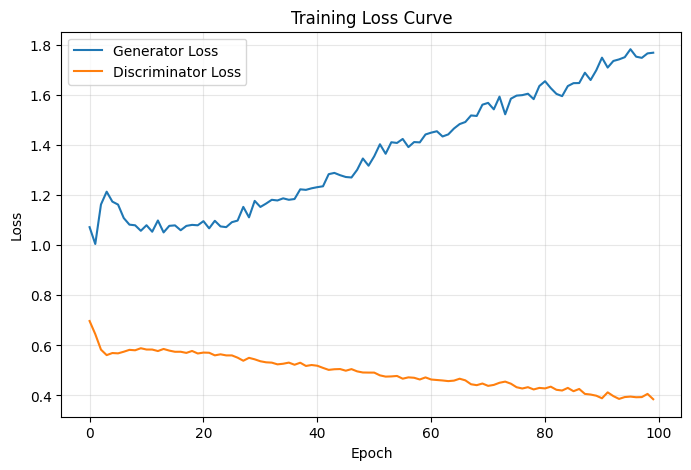

In [ ]:
# ==========================================
# Step 11 : Plot Training Losses
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

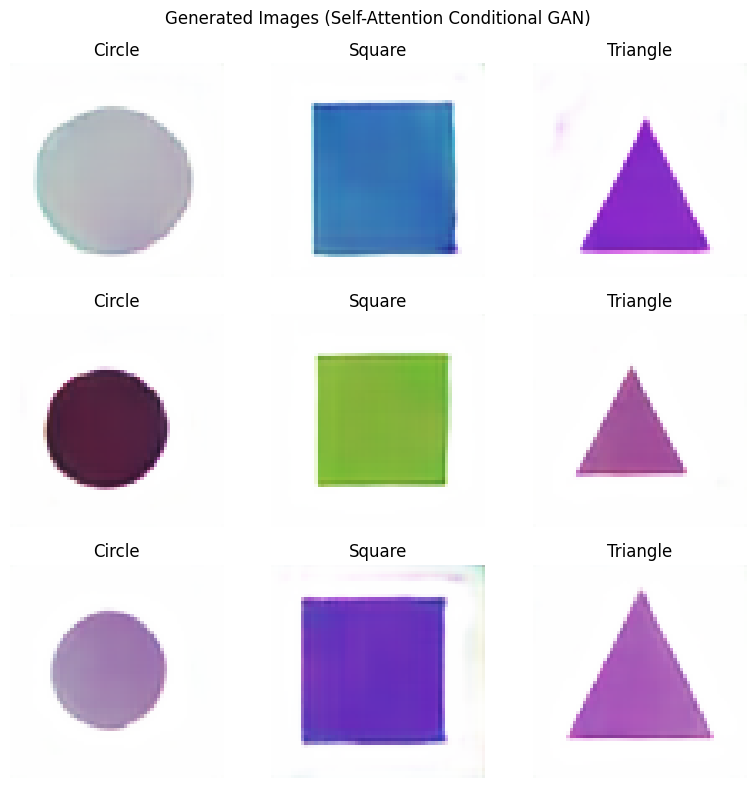

In [ ]:
# ==========================================
# Step 12 : Generate Final Images
# ==========================================

generator.eval()

with torch.no_grad():

    noise = torch.randn(9, LATENT_DIM).to(device)
    labels = torch.tensor([0, 1, 2, 0, 1, 2, 0, 1, 2], device=device)

    fake_images = generator(noise, labels).cpu()

fake_images = (fake_images + 1) / 2
fake_images = fake_images.clamp(0, 1)

class_names = ["Circle", "Square", "Triangle"]

fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for i, ax in enumerate(axes.flatten()):
    image = fake_images[i].permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(class_names[labels[i].item()])
    ax.axis("off")

plt.suptitle("Generated Images (Self-Attention Conditional GAN)")
plt.tight_layout()
plt.savefig("generated_images/final_grid.png")
plt.show()

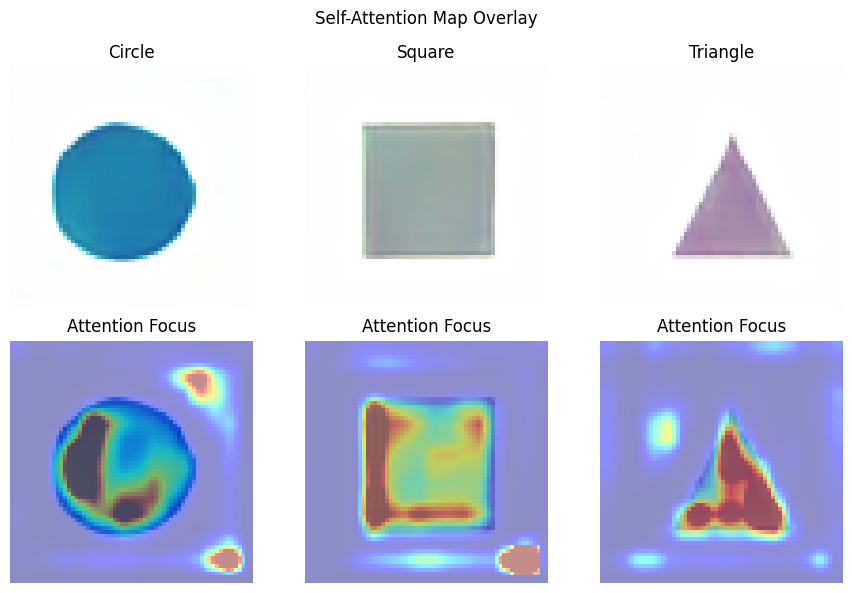

In [ ]:
# ==========================================
# Step 13 : Visualize What the Self-Attention Layer Focuses On
# ==========================================

generator.eval()

with torch.no_grad():
    noise = torch.randn(3, LATENT_DIM, device=device)
    labels = torch.tensor([0, 1, 2], device=device)
    imgs = generator(noise, labels)

attn = generator.attention.attention_map        # shape: B x N x N (N = 16*16)
attn_importance = attn.mean(dim=1)               # average attention received per location
attn_importance = attn_importance.view(-1, 1, 16, 16)

attn_upsampled = torch.nn.functional.interpolate(
    attn_importance, size=(IMAGE_SIZE, IMAGE_SIZE), mode="bilinear", align_corners=False
).cpu().numpy()

imgs = (imgs + 1) / 2
imgs = imgs.clamp(0, 1).cpu()

class_names = ["Circle", "Square", "Triangle"]

fig, axes = plt.subplots(2, 3, figsize=(9, 6))

for i in range(3):
    axes[0, i].imshow(imgs[i].permute(1, 2, 0).numpy())
    axes[0, i].set_title(class_names[labels[i].item()])
    axes[0, i].axis("off")

    heat = attn_upsampled[i, 0]
    vmin, vmax = np.percentile(heat, 5), np.percentile(heat, 95)

    axes[1, i].imshow(imgs[i].permute(1, 2, 0).numpy())
    axes[1, i].imshow(heat, cmap="jet", alpha=0.45, vmin=vmin, vmax=vmax)
    axes[1, i].set_title("Attention Focus")
    axes[1, i].axis("off")

plt.suptitle("Self-Attention Map Overlay")
plt.tight_layout()
plt.show()